In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# Question No1 - Preprocessing
###############################

# Load DataSet
df = pd.read_excel("ABC Company.xlsx")

# Replace the "height" Column with Random Numbers Between 150-180
df["Height"] = np.random.randint(150,180,size=len(df))

# Save the Updated Dataset to CSV
df.to_csv("ABC_Company_Updated.csv", index=False)



In [31]:
# Question No2 - Analysis
##########################

#1 - Count of Employess in Each Team & Percentage Split
df = pd.read_csv("ABC_Company_Updated.csv")
team_count = df["Team"].value_counts()
print("Employee Distibution Across Each Team: ")
print("-" * 40)
print(team_count)
print("*" * 40)

team_percentage = (team_count/len(df)) * 100
print("Percentage Split: ")
print("-" * 20)
print(team_percentage)


Employee Distibution Across Each Team: 
----------------------------------------
Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
Milwaukee Bucks           16
New York Knicks           16
Boston Celtics            15
Los Angeles Clippers      15
Los Angeles Lakers        15
Phoenix Suns              15
Sacramento Kings          15
Brooklyn Nets             15
Philadelphia 76ers        15
Toronto Raptors           15
Golden State Warriors     15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Houston Rockets           15
San Antonio Spurs         15
Atlanta Hawks             15
Dallas Mavericks          15
Charlotte Hornets         15
Miami Heat                15
Denver Nuggets            15
Washington Wizards        15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64
******************

In [43]:
#2 - Seggregate Employees Based on Their Position
position_count = df["Position"].value_counts().reset_index()
position_count.columns = ["Position","Employee Count"]
print("Employee Distribution By Position: ")
print("-" * 35)
print(position_count)


Employee Distribution By Position: 
-----------------------------------
  Position  Employee Count
0       SG             102
1       PF             100
2       PG              92
3       SF              85
4        C              79


In [57]:
#3 - Find the Most Common Age Group in the Company

#age_group = df["Age"].value_counts()
#print("Most Common Age Group: ",age_group.idxmax())

# Create age groups
bins = [20, 30, 40, 50, 60]
labels = ["20-29", "30-39", "40-49", "50-59"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)

# Count employees in each age group
age_group_count = df["Age Group"].value_counts().sort_index()

print("Most Common Age Group: ",age_group_count.idxmax())

Most Common Age Group:  20-29


In [54]:
#4 - Team & Position with Highest Salary Expenditure

team_salary = df.groupby("Team")["Salary"].sum()
print("Team with Highest Salary: ",team_salary.idxmax())
print("Total Salary of the Team: ",team_salary.max())
print("-" * 50)

position_salary = df.groupby("Position")["Salary"].sum()
print("Position with Highest Salary: ",position_salary.idxmax())
print("Total Salary of the Position: ",position_salary.max())


Team with Highest Salary:  Cleveland Cavaliers
Total Salary of the Team:  106988689.0
--------------------------------------------------
Position with Highest Salary:  C
Total Salary of the Position:  466377332.0


Correlation Between Age & Salary:  0.21400941226570971


Text(0, 0.5, 'Salary')

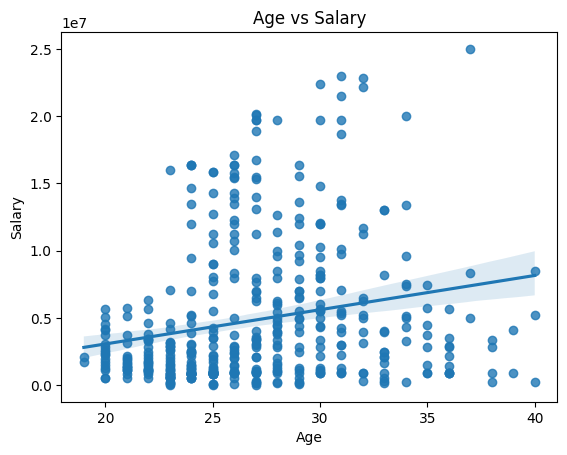

In [65]:
#5 - Find Correlation Between Age & Salary and Represent Visually

correlation = df["Age"].corr(df["Salary"])
print("Correlation Between Age & Salary: ",correlation)

sns.regplot(x="Age",y="Salary",data=df)
plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")




Text(0.5, -0.4, 'Observation: The employees are distributed across multiple teams, most of the teams are having equal employees.')

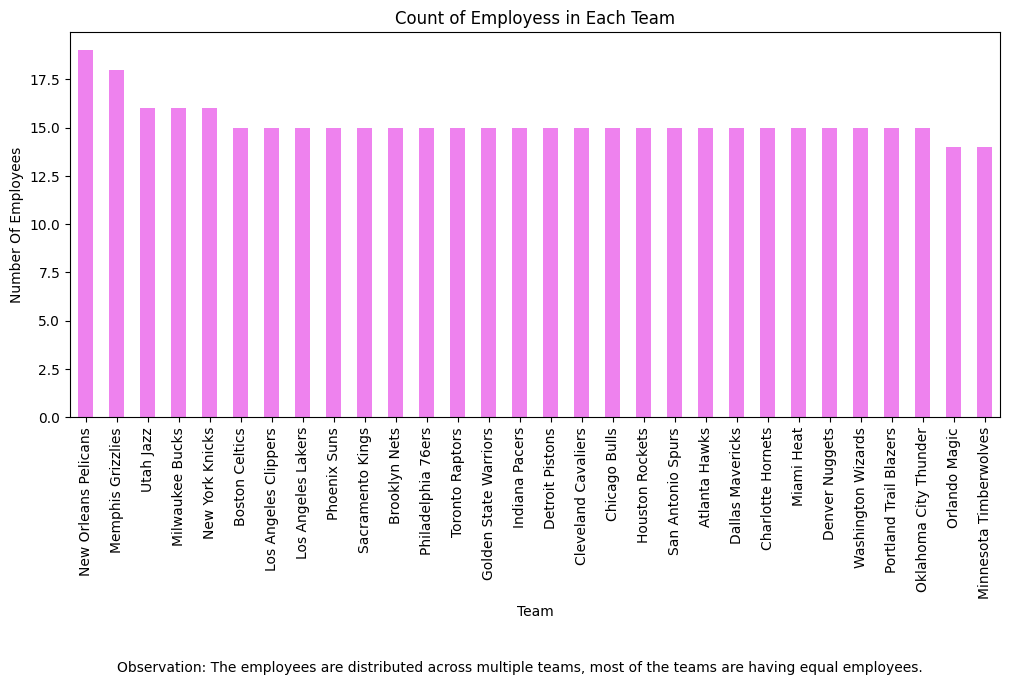

In [98]:
# Question No3 - Graphical Representation
##########################################

#1 - Graphical Representation of Count of Employess in Each Team

team_count = df["Team"].value_counts()
team_count.plot(kind="bar",figsize=(12,5),color="violet")

plt.title("Count of Employess in Each Team")
plt.xlabel("Team")
plt.ylabel("Number Of Employees")
plt.figtext(
    0.5,- 0.40,
    "Observation: The employees are distributed across multiple teams, most of the teams are having equal employees.",
    ha="center",
    fontsize=10
)


Text(0.5, -0.08, 'Observation: Employees are distributed across different positions, Every position is having 75+ Employees.')

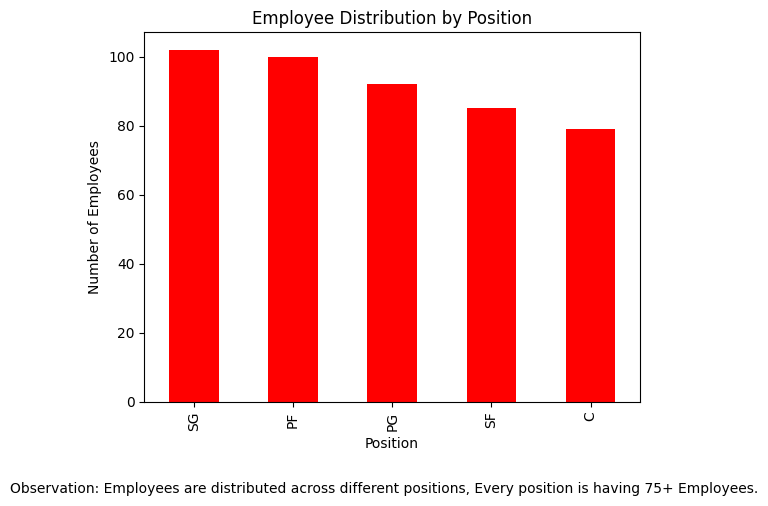

In [102]:
#2 - Graphical Representation of Employee Distribution by Position

position_count = df["Position"].value_counts()
position_count.plot(kind="bar",color="red")

plt.title("Employee Distribution by Position")
plt.xlabel("Position")
plt.ylabel("Number of Employees")
plt.figtext(
    0.5,- 0.08,
    "Observation: Employees are distributed across different positions, Every position is having 60+ Employees.",
    ha="center",
    fontsize=10
)

Text(0.5, -0.08, 'Observation: Most of the employees belong to the 20–29 age group. The number of employees decreases as the age group increases')

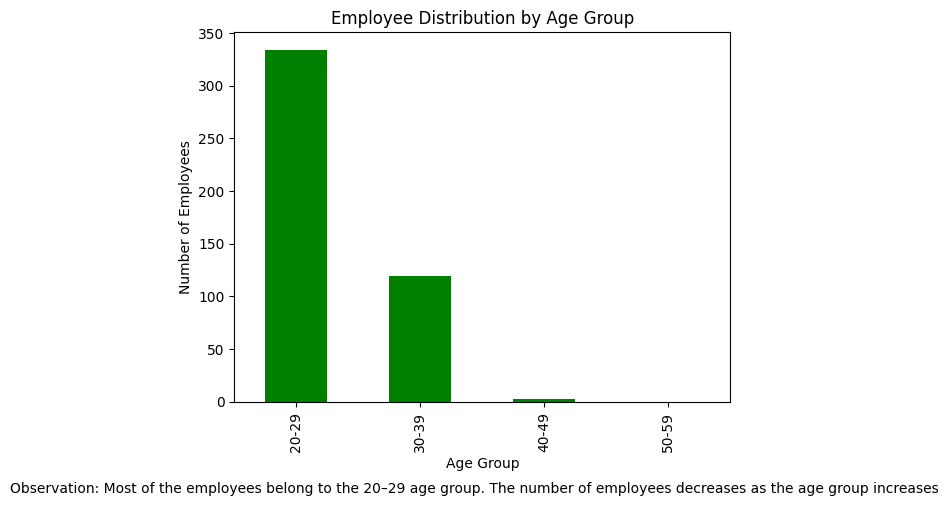

In [103]:
#3 - Graphical Representation of Most Common Age Group in the Company

bins = [20,30,40,50,60]
labels = ["20-29","30-39","40-49","50-59"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)

df["Age Group"].value_counts().plot(kind="bar", color="green")

plt.title("Employee Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.figtext(
    0.5,- 0.08,
    "Observation: Most of the employees belong to the 20–29 age group. The number of employees decreases as the age group increases",
    ha="center",
    fontsize=10
)



Text(0.5, -0.4, 'Observation: The charts identify the team with the highest total salary expenditure. Team with Highest Salary is Charlotte Hornets')

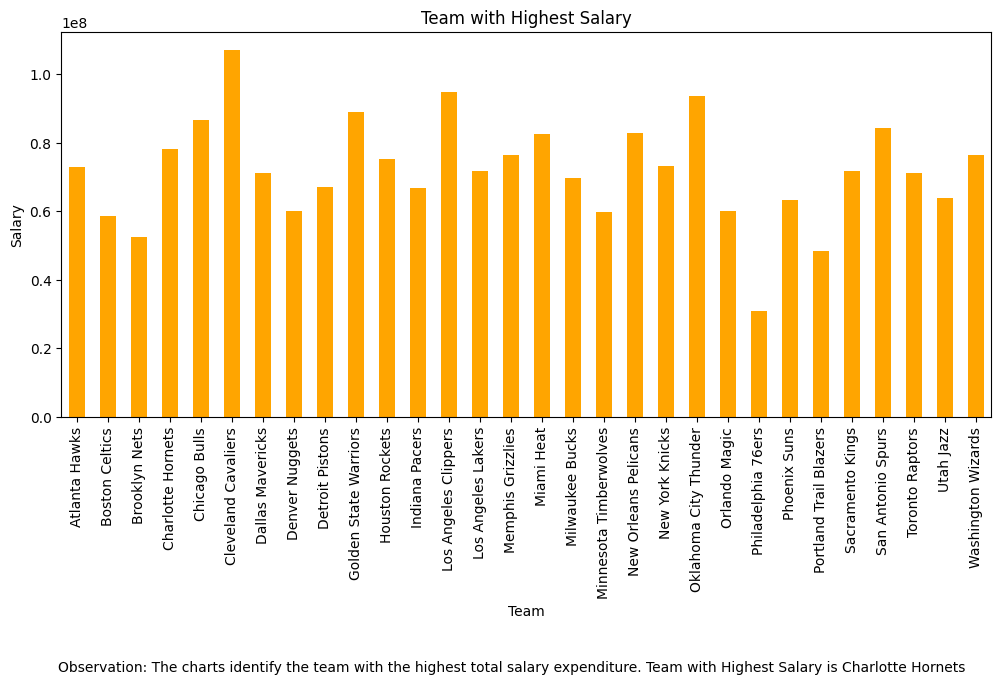

In [113]:
#4 - Graphical Representation of Team with Highest Salary Expenditure

team_salary = df.groupby("Team")["Salary"].sum()
team_salary.plot(kind="bar",figsize=(12,5),color="orange")

plt.title("Team with Highest Salary")
plt.xlabel("Team")
plt.ylabel("Salary")
plt.figtext(
    0.5,- 0.40,
    "Observation: The charts identify the team with the highest total salary expenditure. Team with Highest Salary is Charlotte Hornets",
    ha="center",
    fontsize=10
)

Text(0.5, -0.08, 'Observation: The charts identify the position with the highest total salary expenditure. Here Position with Highest salary is C')

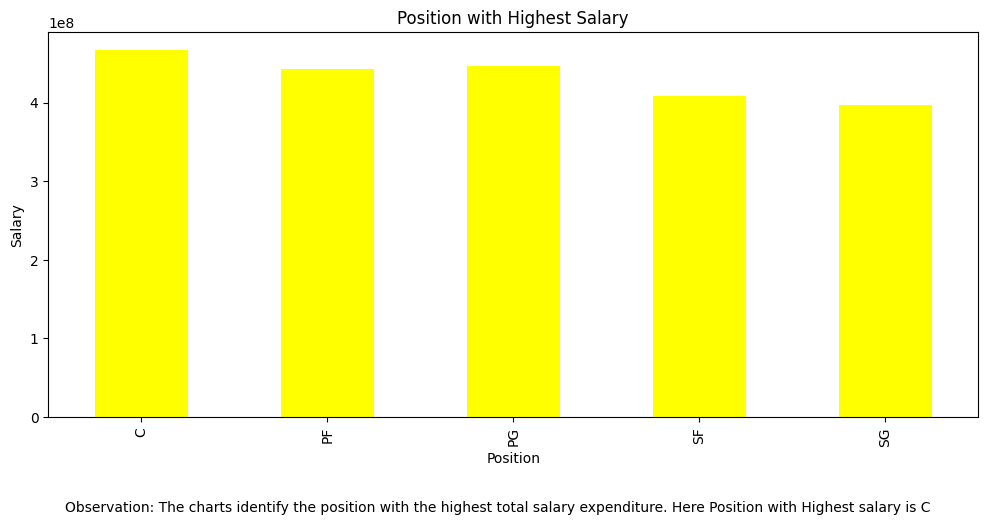

In [112]:
#4.1 - Graphical Representation of Position with Highest Salary Expenditure

position_salary = df.groupby("Position")["Salary"].sum()
position_salary.plot(kind="bar",figsize=(12,5),color="yellow")
plt.title("Position with Highest Salary")
plt.xlabel("Position")
plt.ylabel("Salary")
plt.figtext(
    0.5,- 0.08,
    "Observation: The charts identify the position with the highest total salary expenditure. Here Position with Highest salary is C",
    ha="center",
    fontsize=10
)

Text(0.5, -0.08, 'Observation: There is a slight positive relationship between age and salary, with salaries tending to increase as age increases.')

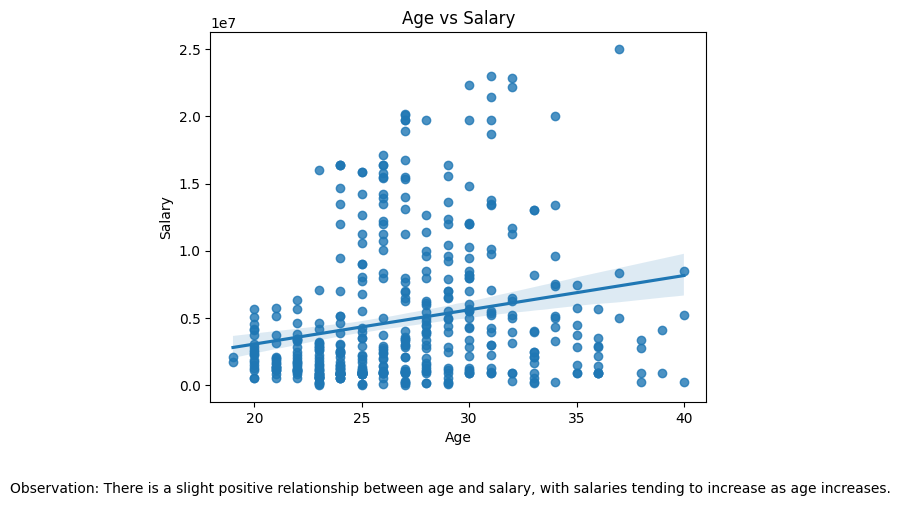

In [114]:
#5 - Graphical Representation of Correlation Between Age & Salary

sns.regplot(x="Age",y="Salary",data=df)
plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.figtext(
    0.5,- 0.08,
    "Observation: There is a slight positive relationship between age and salary, with salaries tending to increase as age increases.",
    ha="center",
    fontsize=10
)